# LSTM — training of the final model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rokhaya8/fall-detection-lstm/blob/main/notebooks/04_lstm_training.ipynb)

Part of [fall-detection-lstm](https://github.com/Rokhaya8/fall-detection-lstm). Paths are set by `BASE_DIR` in the first code cell — adapt it to your Google Drive.

# Montage du drive

In [5]:
# 1. Montage du drive
from google.colab import drive
drive.mount('/content/drive')

# ── Dossier du projet dans Google Drive (à adapter si besoin) ──
import os
BASE_DIR = '/content/drive/MyDrive/Projet_Parkinson'
os.makedirs(f'{BASE_DIR}/Figures', exist_ok=True)


Mounted at /content/drive


# Téléchargement des données

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Charger les données
X_train = np.load(f'{BASE_DIR}/Data_Preprocessed/SisFall/X_train.npy')
X_val   = np.load(f'{BASE_DIR}/Data_Preprocessed/SisFall/X_val.npy')
y_train = np.load(f'{BASE_DIR}/Data_Preprocessed/SisFall/y_train.npy')
y_val   = np.load(f'{BASE_DIR}/Data_Preprocessed/SisFall/y_val.npy')


print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_train : {y_train.shape}")
print(f"Ratio chutes train : {y_train.mean()*100:.1f}%")

X_train : (123031, 200, 6)
X_val   : (15190, 200, 6)
y_train : (123031,)
Ratio chutes train : 34.7%


# Construction,Entraînement du modèle et Sauvegarde

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ===== Hyperparamètres retenus (faithful-sweep-6) =====
LSTM_UNITS    = 128
LSTM_LAYERS   = 1
DROPOUT       = 0.3
BATCH_SIZE    = 256
LEARNING_RATE = 0.0001
EPOCHS        = 100

# ===== Construction du modèle =====
model = Sequential()
model.add(Input(shape=(200, 6)))            # remplace l'ancien input_shape (évite le warning)
model.add(LSTM(units=LSTM_UNITS, return_sequences=False))
model.add(Dropout(DROPOUT))
# (1 seule couche LSTM, comme dans faithful-sweep-6)
model.add(Dense(1, activation='sigmoid'))

# ===== Compilation =====
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

model.summary()

# ===== Callbacks =====
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=f'{BASE_DIR}/Models/LSTM_final.keras',
    monitor='val_loss',
    save_best_only=True
)

# ===== Entraînement =====
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint],
    class_weight={0: 1.0, 1: 3.0}
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,249 (270.50 KB)

 Trainable params: 69,249 (270.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 449s 929ms/step - accuracy: 0.7329 - loss: 0.9202 - precision_1: 0.6080 - recall_1: 0.6507 - val_accuracy: 0.8334 - val_loss: 0.5436 - val_precision_1: 0.7284 - val_recall_1: 0.6978
Epoch 2/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 430s 894ms/step - accuracy: 0.7822 - loss: 0.8316 - precision_1: 0.6895 - recall_1: 0.6791 - val_accuracy: 0.8130 - val_loss: 0.5332 - val_precision_1: 0.6684 - val_recall_1: 0.7320
Epoch 3/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 441s 891ms/step - accuracy: 0.7641 - loss: 0.8086 - precision_1: 0.6414 - recall_1: 0.7279 - val_accuracy: 0.7728 - val_loss: 0.5264 - val_precision_1: 0.5881 - val_recall_1: 0.7778
Epoch 4/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 421s 876ms/step - accuracy: 0.7557 - loss: 0.7931 - precision_1: 0.6212 - recall_1: 0.7605 - val_accuracy: 0.8053 - val_loss: 0.5056 - val_precision_1: 0.6424 - val_recall_1: 0.7736
Epoch 5/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 421s 875ms/step - accuracy: 0.7654 - loss: 0.7767 - precision_1: 0.

KeyboardInterrupt: 

# Comparaison avec les autres modèles de l'équipe

Ce graphique compare le LSTM (ce notebook) aux modèles **GRU** et **CNN**, réalisés par d'autres membres de l'équipe et non inclus dans ce dépôt. Toutes les valeurs sont mesurées sur le même jeu de test SisFall, avec un seuil de 0,40.

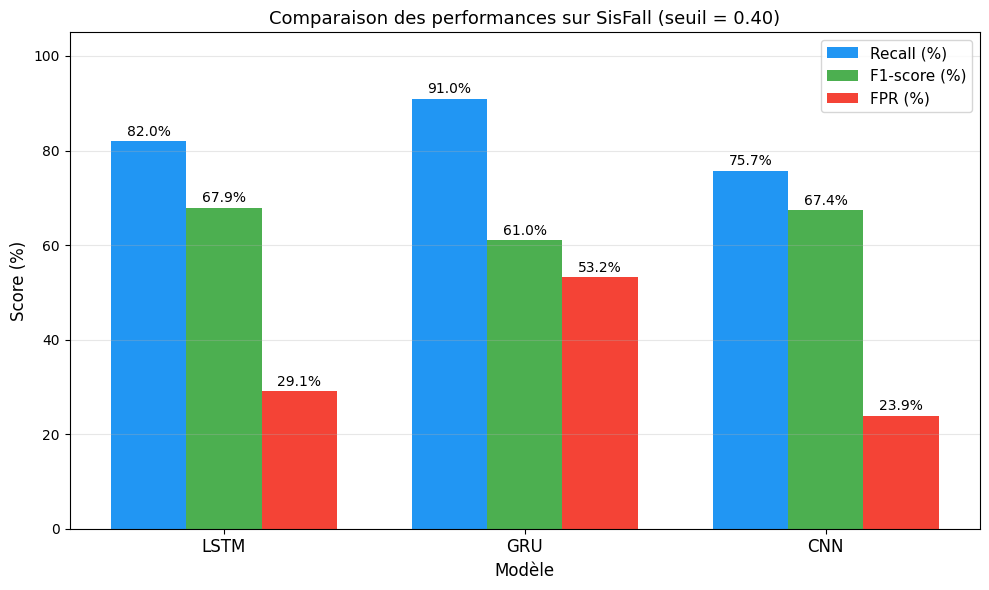

✅ Graphique sauvegardé sur Drive


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Données mises à jour
modeles = ['LSTM', 'GRU', 'CNN']
recall  = [82.0, 91.0, 75.7]
f1      = [67.9, 61.0, 67.4]
fpr     = [29.1, 53.24, 23.9]

x = np.arange(len(modeles))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, recall, width, label='Recall (%)', color='#2196F3')
bars2 = ax.bar(x,         f1,     width, label='F1-score (%)', color='#4CAF50')
bars3 = ax.bar(x + width, fpr,    width, label='FPR (%)', color='#F44336')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparaison des performances sur SisFall (seuil = 0.40)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(modeles, fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/Figures/model_comparison.png', dpi=150)
plt.show()
print("✅ Graphique sauvegardé sur Drive")